My name is Qurban.

Am student of Bs Mds

My first project is going to be a Moving average 

In [1]:
#import libraries
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
#load data set
df =pd.read_csv("stock.csv")
df

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0
...,...,...,...,...,...,...,...,...
112452,N100,5/27/2021,1241.119995,1251.910034,1241.119995,1247.069946,1247.069946,379696400.0
112453,N100,5/28/2021,1249.469971,1259.209961,1249.030029,1256.599976,1256.599976,160773400.0
112454,N100,5/31/2021,1256.079956,1258.880005,1248.140015,1248.930054,1248.930054,91173700.0
112455,N100,6/1/2021,1254.609985,1265.660034,1254.609985,1258.579956,1258.579956,155179900.0


In [ ]:
#check null values 
df.isnull().sum()

Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64

In [ ]:
#all missing value are numeric we can replace them with mean , median , mode ,and 0
df.fillna({"Open" : df["Open"].mean , "Close": df["Close"].mean ,}, inplace=True)

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0
...,...,...,...,...,...,...,...,...
112452,N100,5/27/2021,1241.119995,1251.910034,1241.119995,1247.069946,1247.069946,379696400.0
112453,N100,5/28/2021,1249.469971,1259.209961,1249.030029,1256.599976,1256.599976,160773400.0
112454,N100,5/31/2021,1256.079956,1258.880005,1248.140015,1248.930054,1248.930054,91173700.0
112455,N100,6/1/2021,1254.609985,1265.660034,1254.609985,1258.579956,1258.579956,155179900.0


In [31]:
df["Close"].tail(20)

112437    1240.099976
112438    1248.140015
112439    1243.630005
112440     1219.76001
112441    1220.079956
112442    1220.459961
112443    1237.890015
112444    1234.689941
112445    1233.800049
112446     1215.27002
112447    1232.280029
112448    1238.920044
112449    1243.900024
112450     1243.73999
112451    1243.420044
112452    1247.069946
112453    1256.599976
112454    1248.930054
112455    1258.579956
112456    1263.619995
Name: Close, dtype: object

In [34]:
df["Close"]=pd.to_numeric(df["Close"] , errors = "coerce")

In [35]:
df["Close"].dtypes

dtype('float64')

moving average of 7 day mean : the average price of last 7 day and at new day the last day get remove and new day come in)

In [ ]:
#moving average need this function 
df["Ma_20days"]= df["Close"].rolling(window=20).mean()
df["Ma_20days"].tail(20)

112437    1227.797498
112438    1229.346497
112439    1230.917499
112440    1231.101502
112441    1231.025501
112442    1230.689002
112443    1230.845001
112444    1230.912500
112445    1232.095001
112446    1231.750000
112447    1231.746503
112448    1232.103003
112449    1232.617505
112450    1233.223505
112451    1233.591504
112452    1234.194000
112453    1235.604999
112454    1236.279504
112455    1238.303504
112456    1239.544000
Name: Ma_20days, dtype: float64

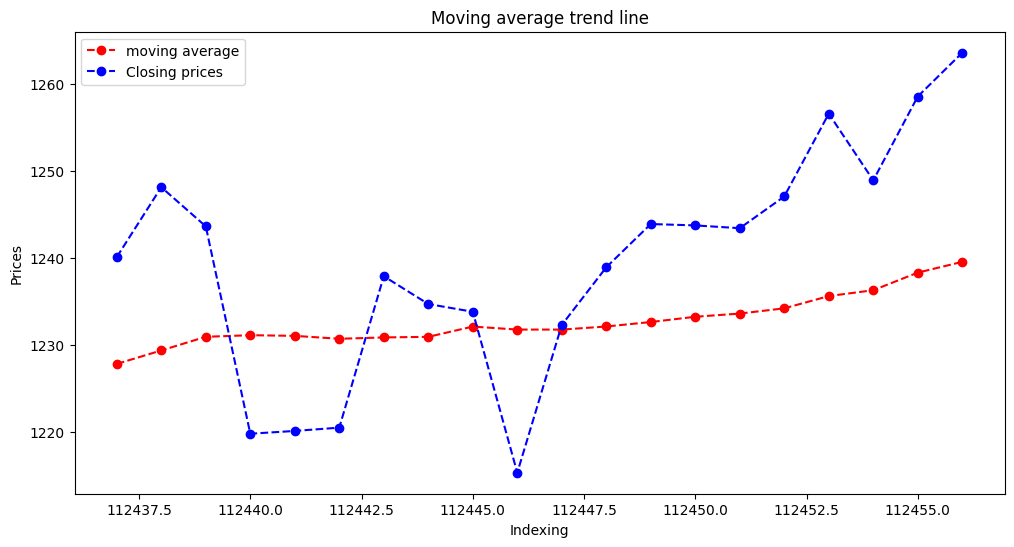

In [55]:
#plot a Graph
plt.figure(figsize=(12 , 6))
plt.plot(df['Ma_20days'].tail(20), marker='o' , linestyle='--' , color='red' , label="moving average" )
plt.plot(df["Close"].tail(20) , marker='o' , linestyle='--' ,  color='blue' , label = "Closing prices")
plt.xlabel("Indexing")
plt.title("Moving average trend line")
plt.ylabel("Prices")
plt.legend()
plt.ticklabel_format(useOffset=False , style="Plain" , axis='x')#to change the indexing into exact format , otherwise it will be in small decimal values(confusing)
plt.show()

for 100 day moving average , i replace marker o to , 

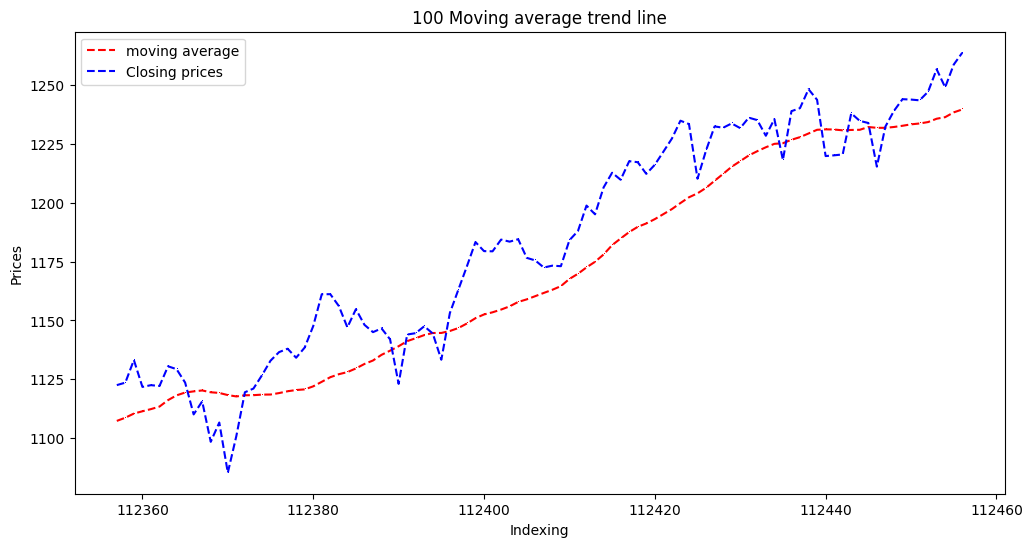

In [52]:
#plot a Graph
plt.figure(figsize=(12 , 6))
plt.plot(df['Ma_20days'].tail(100), marker=',' , linestyle='--' , color='red' , label="moving average" )
plt.plot(df["Close"].tail(100) , marker=',' , linestyle='--' ,  color='blue' , label = "Closing prices")
plt.xlabel("Indexing")
plt.title("100 Moving average trend line")
plt.ylabel("Prices")
plt.legend()
plt.show()

### Due to some lack in simple moving average , here is SMA that give more accuracy using weight for current value

In [57]:
#Average value using ewm(exponential weight moving)
EMA_20days=df["Close"].ewm(span=20 , adjust=False).mean()
EMA_20days.tail(20)

112437    1224.761045
112438    1226.987614
112439    1228.572603
112440    1227.733309
112441    1227.004418
112442    1226.381136
112443    1227.477220
112444    1228.164146
112445    1228.700898
112446    1227.421767
112447    1227.884459
112448    1228.935467
112449    1230.360663
112450    1231.634884
112451    1232.757281
112452    1234.120392
112453    1236.261304
112454    1237.467852
112455    1239.478529
112456    1241.777716
Name: Close, dtype: float64

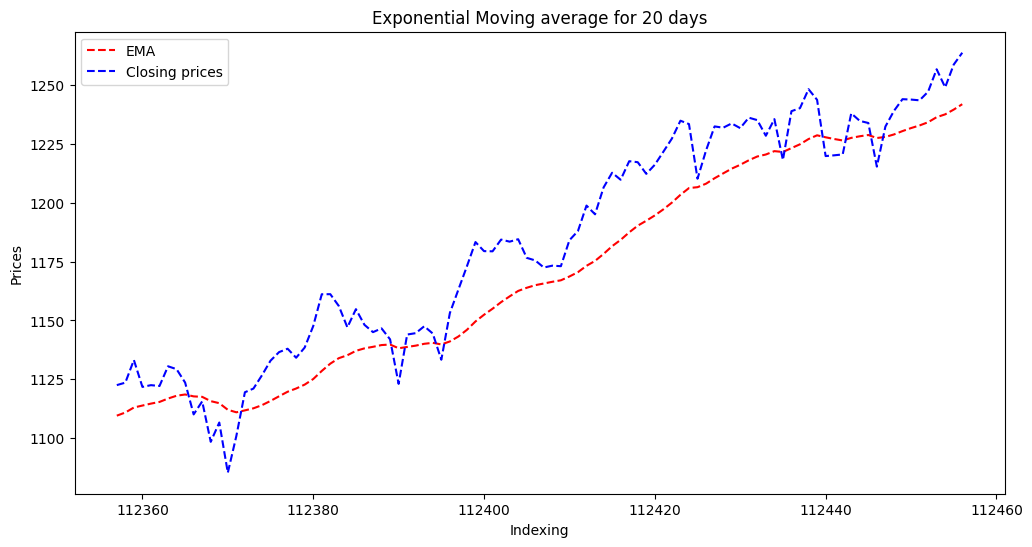

In [61]:
plt.figure(figsize=(12 , 6))
plt.plot(EMA_20days.tail(100), marker='' , linestyle='--' , color='red' , label="EMA" )
plt.plot(df["Close"].tail(100) , marker='' , linestyle='--' ,  color='blue' , label = "Closing prices")
plt.xlabel("Indexing")
plt.title("Exponential Moving average for 20 days")
plt.ylabel("Prices")
plt.legend()
plt.show()

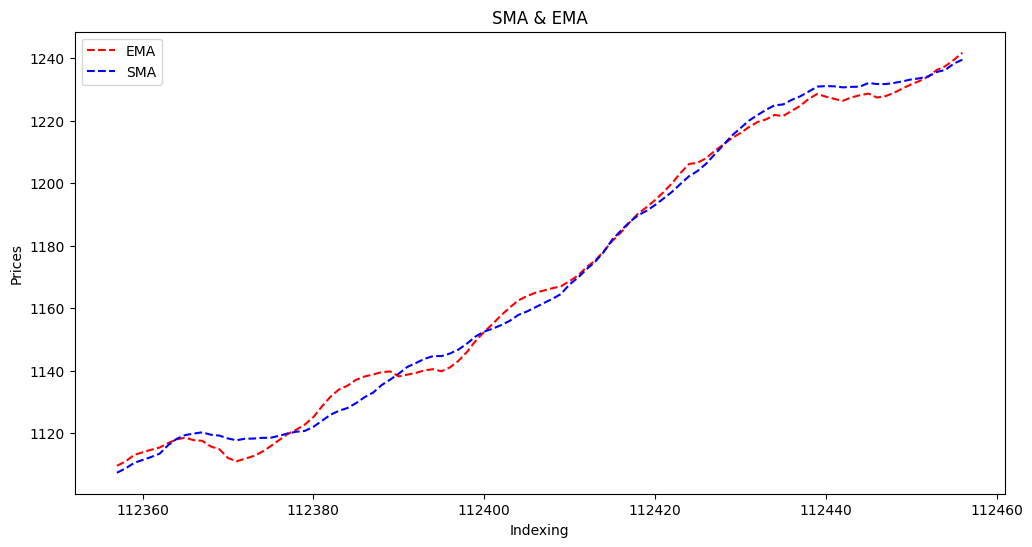

In [64]:
plt.figure(figsize=(12 , 6))
plt.plot(EMA_20days.tail(100), marker='' , linestyle='--' , color='red' , label="EMA" )
plt.plot(df["Ma_20days"].tail(100) , marker='' , linestyle='--' ,  color='blue' , label = "SMA")
plt.xlabel("Indexing")
plt.title("SMA & EMA")
plt.ylabel("Prices")
plt.legend()
plt.show()